Script to download data from DMI.  We use the API from DMI whihc is described here:
https://www.dmi.dk/friedata/dokumentation/apis/climate-data-api-1




In [2]:
# required packages
import os
import requests
#from zipfile import ZipFile
#from io import BytesIO
#import xarray as xa
import json
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd


In [3]:
# number of data points?
# 16 year of 12 months over 178 grid squares
print(20*12*178)

42720


In [4]:
url = 'https://opendataapi.dmi.dk/v2/climateData/collections/20kmGridValue/items?' \
    'datetime=2010-01-01T00:00:00%2B02:00/2026-01-01T00:00:00%2B02:00' \
    '&parameterId=mean_temp' \
    '&timeResolution=month' \
    '&limit=42720'
response = requests.get(url, timeout=30)
print(response.status_code)

200


In [5]:
# extract API response to JSON data object
response.status_code
data = response.json()
print(data['features'][1])

{'type': 'Feature', 'id': '1f66eb44-4bef-0ca5-0f26-82e1bf9ca88d', 'geometry': {'type': 'Polygon', 'coordinates': [[[11.2101, 55.3863], [11.5255, 55.3802], [11.537, 55.5597], [11.2201, 55.5659], [11.2101, 55.3863]]]}, 'properties': {'parameterId': 'mean_temp', 'qcStatus': 'manual', 'created': '2026-05-20T01:18:50+00:00', 'timeResolution': 'month', 'from': '2025-12-01T00:00:00.001000+01:00', 'to': '2026-01-01T00:00:00+01:00', 'cellId': '20km_614_64', 'value': 5.1, 'calculatedAt': '2026-05-20T00:51:05.884000'}}


In [6]:
# create geodateframe with GeoPandas
geo_data = gpd.GeoDataFrame.from_features(data['features'])
print(geo_data[:5])

                                            geometry parameterId qcStatus  \
0  POLYGON ((10.9032 55.5712, 11.2201 55.5659, 11...   mean_temp   manual   
1  POLYGON ((11.2101 55.3863, 11.5255 55.3802, 11...   mean_temp   manual   
2  POLYGON ((11.2201 55.5659, 11.537 55.5597, 11....   mean_temp   manual   
3  POLYGON ((11.4807 54.6619, 11.7904 54.6552, 11...   mean_temp   manual   
4  POLYGON ((10.3369 57.5554, 10.671 57.5514, 10....   mean_temp   manual   

                     created timeResolution                              from  \
0  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   
1  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   
2  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   
3  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   
4  2026-05-20T01:18:50+00:00          month  2025-12-01T00:00:00.001000+01:00   

                          to       cellId  value  

In [7]:
# add column with month, year

def translate_time(from_time):
    '''
    Function translates from_time in the ISO 8601 international standard formate to month as
    three letter string and year as str

    Arg:
        from_time: (str) time data in ISO 8601 formate
    '''
    
    months = {'01':'JAN', '02':'FEB', '03':'MAR', '04':'APR', '05':'MAY', '06':'JUN', '07':'JUL', 
              '08':'AUG', '09':'SEP', '10':'OCT', '11':'NOV', '12':'DEC'}

    from_time_as_list = from_time.split('-')

    year = from_time_as_list[0]
    month = months[from_time_as_list[1]]
    
    return year, month

# test
print(translate_time('2026-01-01T00:00:00+01:00'))

# Adding year and data as column
geo_data = geo_data.assign(Year = [translate_time(time_from)[0] for time_from in geo_data['from']],
                        Month = [translate_time(time_from)[1] for time_from in geo_data['from']])

# investigating data
print('min and max year', min(geo_data['Year']), max(geo_data['Year']))
print('min and max temp', min(geo_data['value']), max(geo_data['value']))

('2026', 'JAN')
min and max year 2011 2025
min and max temp -1.4 21.2


Text(0.5, 1.0, 'Mean temperature December 2025')

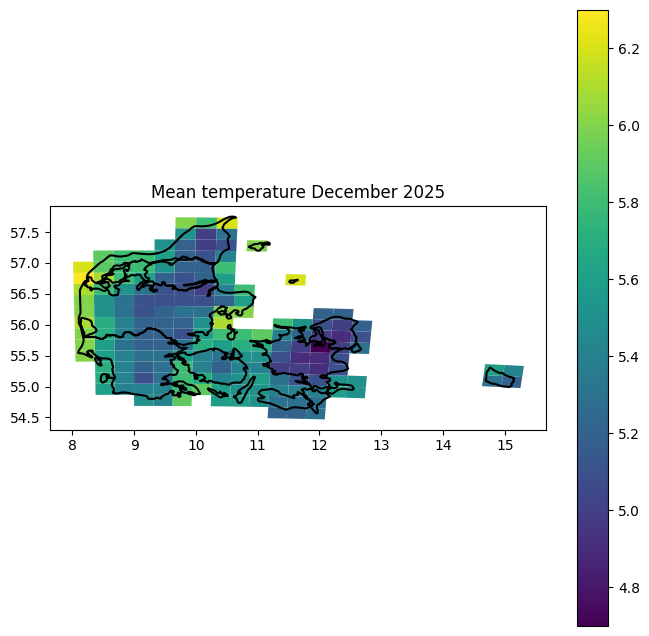

In [9]:
# Mean temperatures for december 2025
geo_data_dec_2025 = geo_data[(geo_data["Year"] == "2025") & (geo_data["Month"] == "DEC")]

# Import DK GeoJSON
# from https://simplemaps.com/gis/country/dk
dk = gpd.GeoDataFrame.from_file('../dk.json')

# Plot
fig, ax = plt.subplots(figsize=(8,8))
dk.boundary.plot(ax=ax, color='k')
temp_cmap = geo_data_dec_2025.plot(ax=ax, column='value', legend=True)

ax.set_title('Mean temperature December 2025')

#### Animation
We make an animation of the temperature over the 16 year period.

minumum and maximum temp. in dataset = -1.4 21.2
('2012', 'JAN')


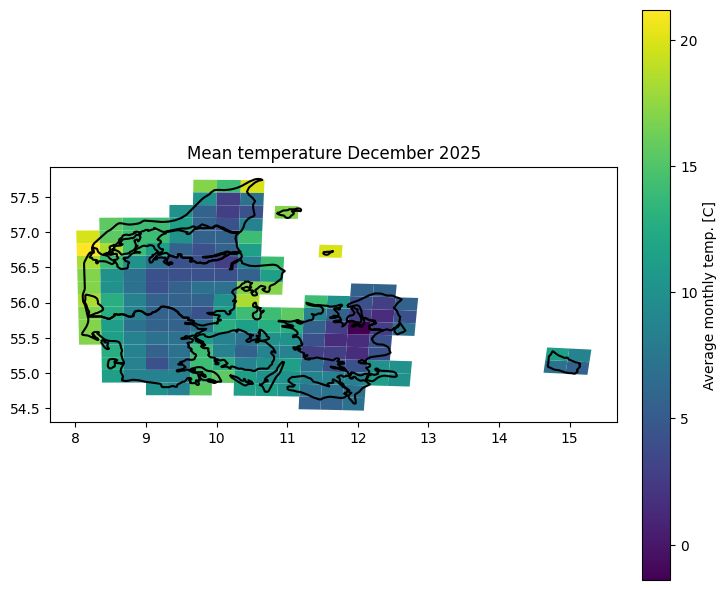

In [10]:
from matplotlib.animation import FuncAnimation

# Mean temperatures for december 2025
geo_data_dec_2025 = geo_data[(geo_data["Year"] == "2025") & (geo_data["Month"] == "DEC")]


# Plot
fig, ax = plt.subplots(figsize=(8,8))
dk.boundary.plot(ax=ax, color='k')
temp_cmap = geo_data_dec_2025.plot(ax=ax, 
                                   column='value',
                                   cmap = 'viridis',
                                   legend=False)

title = ax.set_title('Mean temperature December 2025')


# we normalise the tempertures as t' = (t-min(t))/(max(t)-min(t))
max_t = np.max(geo_data['value'])
min_t = np.min(geo_data['value'])
print('minumum and maximum temp. in dataset =', min_t, max_t)

# Create a Normalize object
norm = plt.Normalize(vmin=min_t, vmax=max_t)

# Create a fake mappable for the legend
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([]) # The array is empty because we don't need data points here

# Add the colorbar to the figure
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Average monthly temp. [C]')

def calc_year_month(i):
    initial_year = 2011

    year  = str(initial_year + (i)//12)
    months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    month = months[(i)%12]

    return year, month

def update(i):
    
    # year and month
    year, month = calc_year_month(i)
    
    # extract data
    current_data = geo_data[(geo_data["Year"] == year) & (geo_data["Month"] == month)]

    # update the data
    temp_cmap = current_data.plot(
        ax = ax,
        column = 'value',
        cmap = 'viridis',
        legend = False,
        vmin = min_t,
        vmax = max_t
    )

    title = ax.set_title('Mean temperature {} {}'.format(month, year))

    return (temp_cmap, title)

    
print(calc_year_month(12))

In [ ]:
anim = FuncAnimation(fig, func=update, frames=12*15, interval=100, repeat=False)
anim.save('../Media/WeatherDenmark.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.
